<a href="https://colab.research.google.com/github/TaruniRavipudi/RavipudiTaruni_Projects_and_Labs/blob/main/Taruni_Module5_Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')

# interactive visualization

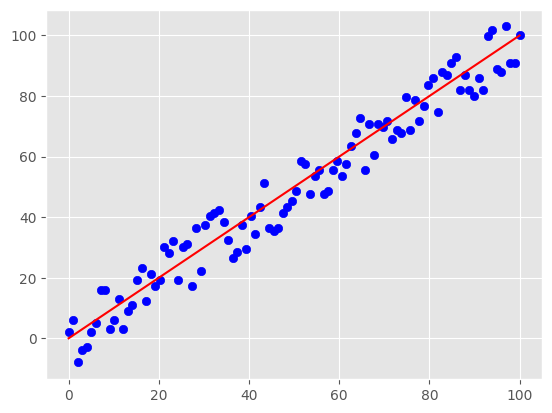

In [15]:
# initializing random data

np.random.seed(0)
x = np.linspace(0,100,100)
y_actual = np.copy(x)
y_pred = x + np.random.randint(-10,10,100)

plt.plot(x,y_actual,color="red")
plt.scatter(x,y_pred,color="blue")
plt.show()

In [16]:
mse = np.mean((y_actual-y_pred)**2)
print("MSE is: {}".format(mse))
print("RMSE is: {}".format(np.sqrt(mse)))

MSE is: 38.68
RMSE is: 6.219324722186485


In [17]:
mae = np.mean(np.abs(y_actual-y_pred))
print("MAE is: {}".format(mae))

MAE is: 5.5


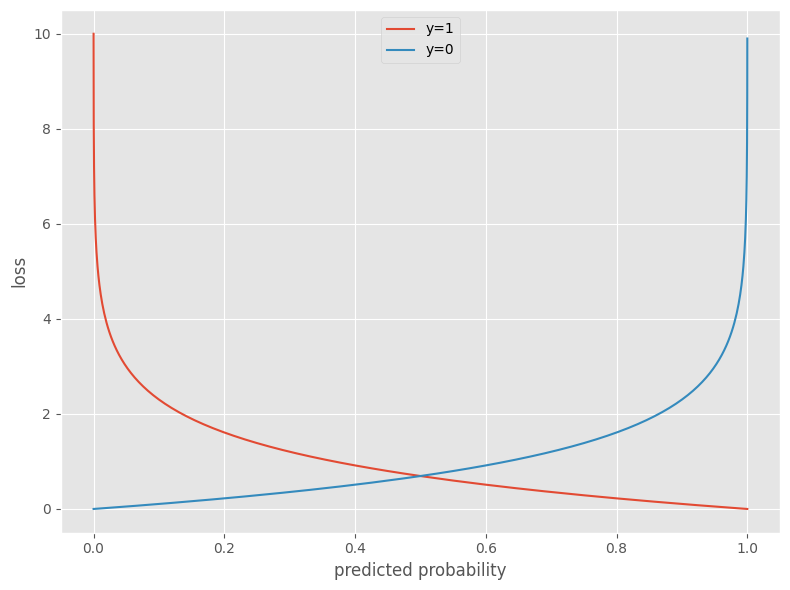

In [18]:
def sigmoid(z):
  return 1/(1 + np.exp(-z))

def cross_entropy_loss(y_,y):
  if y==1:
    return -np.log(y_)

  return -np.log(1-y_)

z = np.arange(-10, 10, 0.1)
h_z = sigmoid(z)

cost_1 = cross_entropy_loss(h_z, 1)
cost_0 = cross_entropy_loss(h_z, 0)

fig, ax = plt.subplots(figsize=(8,6))
plt.plot(h_z, cost_1, label='y=1')
plt.plot(h_z, cost_0, label='y=0')
plt.xlabel('predicted probability')
plt.ylabel('loss')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

In [19]:
from sklearn import neighbors
from sklearn.metrics import mean_squared_error
from math import sqrt
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import numpy as np

In [20]:
train_path = "https://raw.githubusercontent.com/PranavTadimeti/Regression-lab2/main/BigMart-train.csv"

train = pd.read_csv(train_path)

In [21]:
# Preprocess Data

def preprocess(df):
  mean_weight = df['Item_Weight'].mean()
  df['Item_Weight'].fillna(mean_weight,inplace=True)

  mode_size = df['Outlet_Size'].mode()
  df['Outlet_Size'].fillna(mode_size,inplace=True)

  df.drop(['Item_Identifier','Outlet_Identifier'],axis=1,inplace=True)

  return pd.get_dummies(df)

train = preprocess(train)

train.head()

/tmp/ipykernel_1582/319556835.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Item_Weight'].fillna(mean_weight,inplace=True)
/tmp/ipykernel_1582/319556835.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales,Item_Fat_Content_LF,Item_Fat_Content_Low Fat,Item_Fat_Content_Regular,Item_Fat_Content_low fat,Item_Fat_Content_reg,...,Outlet_Size_High,Outlet_Size_Medium,Outlet_Size_Small,Outlet_Location_Type_Tier 1,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Grocery Store,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,9.30,0.016047,249.8092,1999,3735.1380,False,True,False,False,False,...,False,True,False,True,False,False,False,True,False,False
1,5.92,0.019278,48.2692,2009,443.4228,False,False,True,False,False,...,False,True,False,False,False,True,False,False,True,False
2,17.50,0.016760,141.6180,1999,2097.2700,False,True,False,False,False,...,False,True,False,True,False,False,False,True,False,False
3,19.20,0.000000,182.0950,1998,732.3800,False,False,True,False,False,...,False,False,False,False,False,True,True,False,False,False
4,8.93,0.000000,53.8614,1987,994.7052,False,True,False,False,False,...,True,False,False,False,False,True,False,True,False,False


In [22]:
train , test = train_test_split(train, test_size = 0.3)

x_train = train.drop('Item_Outlet_Sales', axis=1)
y_train = train['Item_Outlet_Sales']

x_test = test.drop('Item_Outlet_Sales', axis = 1)
y_test = test['Item_Outlet_Sales']

In [23]:
scaler = MinMaxScaler(feature_range=(0, 1))

x_train_scaled = scaler.fit_transform(x_train)
x_train = pd.DataFrame(x_train_scaled)

x_test_scaled = scaler.fit_transform(x_test)
x_test = pd.DataFrame(x_test_scaled)

In [24]:
def knn_regression(k,x_train,y_train,x_test,y_test):
    model = neighbors.KNeighborsRegressor(n_neighbors = k)

    model.fit(x_train, y_train)
    pred=model.predict(x_test)
    error = sqrt(mean_squared_error(y_test,pred))
    rmse_val.append(error)

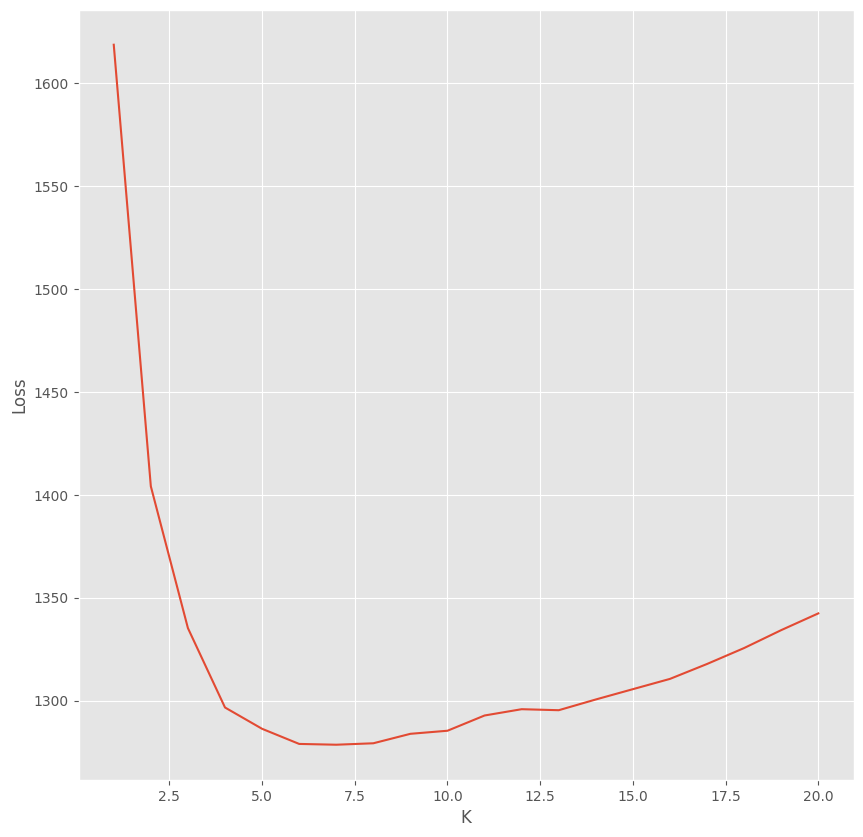

Minimum error 1278.5816281094171 is at k = 6


In [25]:
rmse_val = []

for k in range(1,21):
  knn_regression(k,x_train,y_train,x_test,y_test)

figure = plt.figure(figsize=(10,10))
plt.plot(np.arange(1,21),rmse_val)
plt.xlabel("K")
plt.ylabel("Loss")
plt.show()

rmse_val = np.asarray(rmse_val)
print("Minimum error {} is at k = {}".format(np.min(rmse_val),np.argmin(rmse_val)))

In [27]:
from sklearn import neighbors

k = 5

model = neighbors.KNeighborsRegressor(n_neighbors=k)
model.fit(x_train, y_train)

pred = model.predict(x_test)

In [28]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Predict using the trained model
pred = model.predict(x_test)

# Mean Squared Error
mse = mean_squared_error(y_test, pred)

# Root Mean Squared Error
rmse = np.sqrt(mse)

# Mean Absolute Error
mae = mean_absolute_error(y_test, pred)

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("Mean Absolute Error (MAE):", mae)

Mean Squared Error (MSE): 1654602.7916339007
Root Mean Squared Error (RMSE): 1286.3136443472488
Mean Absolute Error (MAE): 920.5455474071177


In [29]:
delta = 1.0

errors = y_test - pred

huber_loss = np.where(np.abs(errors) <= delta,
                      0.5 * errors**2,
                      delta * (np.abs(errors) - 0.5 * delta))

print("Huber Loss:", np.mean(huber_loss))

Huber Loss: 920.0456606354401


In [30]:
log_cosh = np.mean(np.log(np.cosh(pred - y_test)))

print("Log-Cosh Loss:", log_cosh)

Log-Cosh Loss: inf


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in cosh
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [31]:
from sklearn import neighbors

k = 5   # or use the best K from your experiment

model = neighbors.KNeighborsRegressor(n_neighbors=k)
model.fit(x_train, y_train)

pred = model.predict(x_test)

In [32]:
import numpy as np

delta = 1.0

errors = y_test - pred

huber_loss = np.where(
    np.abs(errors) <= delta,
    0.5 * errors**2,
    delta * (np.abs(errors) - 0.5 * delta)
)

print("Huber Loss:", np.mean(huber_loss))

Huber Loss: 920.0456606354401


In [33]:
import numpy as np

log_cosh = np.mean(np.log(np.cosh(pred - y_test)))

print("Log-Cosh Loss:", log_cosh)

Log-Cosh Loss: inf


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in cosh
  result = getattr(ufunc, method)(*inputs, **kwargs)


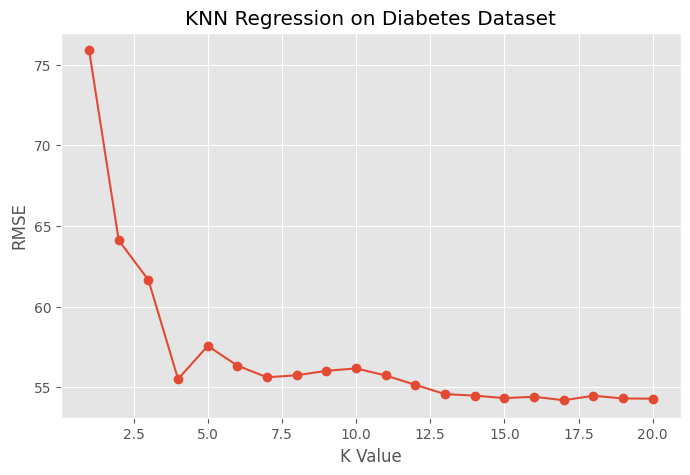

Best K = 17
Minimum RMSE = 54.20477717618848


In [34]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Load Diabetes dataset
diabetes = load_diabetes()

X = diabetes.data
y = diabetes.target

# Split dataset
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Scale the features
scaler = MinMaxScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# Test different K values
rmse = []

for k in range(1, 21):
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(x_train, y_train)

    pred = model.predict(x_test)

    error = np.sqrt(mean_squared_error(y_test, pred))
    rmse.append(error)

# Plot RMSE vs K
plt.figure(figsize=(8,5))
plt.plot(range(1,21), rmse, marker='o')
plt.xlabel("K Value")
plt.ylabel("RMSE")
plt.title("KNN Regression on Diabetes Dataset")
plt.grid(True)
plt.show()

# Best K
best_k = np.argmin(rmse) + 1

print("Best K =", best_k)
print("Minimum RMSE =", min(rmse))

In [35]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Load dataset
diabetes = load_diabetes()

X = diabetes.data
y = diabetes.target

# Split the dataset
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Scale the data
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# -------- K = 1 --------
model1 = KNeighborsRegressor(n_neighbors=1)
model1.fit(x_train, y_train)

pred1 = model1.predict(x_test)

rmse1 = np.sqrt(mean_squared_error(y_test, pred1))

print("K = 1")
print("RMSE =", rmse1)

# -------- K = Size of Training Dataset --------
k_max = len(x_train)

model2 = KNeighborsRegressor(n_neighbors=k_max)
model2.fit(x_train, y_train)

pred2 = model2.predict(x_test)

rmse2 = np.sqrt(mean_squared_error(y_test, pred2))

print("\nK =", k_max)
print("RMSE =", rmse2)

K = 1
RMSE = 75.89005700274377

K = 309
RMSE = 73.70811591190015
